<a href="https://colab.research.google.com/github/mahihshah/dark-output-adoi/blob/main/Asia_Dark_Output_Index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Asia Dark Output Index (ADOI)
### A pre-emptive index for AI-driven economic activity *not yet captured in GDP*

---

## 1. Why "Dark Output"?

Standard GDP accounting struggles to capture productivity gains that occur **off the books** (in informal markets, gig work, and self-employment) especially when those gains are *augmented by AI tools* (chatbots, AI-assisted freelancing, automated translation/design work, etc) rather than formal automation investment by registered firms.

**Dark Output** = economic value created with the help of AI that is likely to slip through formal statistical capture, because it happens in informal, self-employed, or under-the-radar segments of the economy

The **Asia Dark Output Index (ADOI)** combines four signals to *pre-emptively* flag which countries are most exposed to this phenomenon — i.e., where the *conditions* for untracked AI-driven output are strongest, **before** it shows up (or fails to show up) in official statistics.

---

## 2. The Four Pillars

| Pillar | Indicator | Source | Why it matters |
|---|---|---|---|
| **Informal Employment** | Informal employment rate (% of total employment) | ILOSTAT | Informal workers' output is the *least* likely to be captured in GDP — if they adopt AI tools, the productivity gain vanishes from official stats entirely |
|  **Self-Employment** | Self-employment rate (% of total employment) | World Bank (modeled ILO estimate) | Self-employed/gig workers are early, individual adopters of AI tools (e.g. freelancers using AI for design, writing, translation) with no firm-level reporting |
| **AI Exposure** | Share of tasks exposed to AI + Share highly exposed | Global Automation Atlas | Measures how much of the *existing task mix* in a country's economy is technically exposed to AI — the raw material for dark output |
| **Digital Infrastructure** | Internet penetration (% of population) | World Bank | A **necessary enabler** — without connectivity, AI exposure cannot translate into actual usage or output |

> **Note on direction:** all four pillars are coded so that a **higher value → higher dark output potential**. More informality, more self-employment, more AI task exposure, *and* more internet access all independently raise the likelihood that AI-driven productivity gains go statistically dark.

---

## 3. The Formula

Each raw indicator is first **min-max normalized** across the 12 countries to a common $[0, 1]$ scale, then combined using the weights below:

$$
\text{ADOI}_{c} \;=\; 100 \times \Big[
\underbrace{0.30 \cdot \widetilde{IE}_c}_{\text{Informal Employment}}
\;+\;
\underbrace{0.30 \cdot \widetilde{SE}_c}_{\text{Self-Employment}}
\;+\;
\underbrace{\big(0.10 \cdot \widetilde{AX}_c \;+\; 0.10 \cdot \widetilde{AH}_c\big)}_{\text{AI Exposure (20%)}}
\;+\;
\underbrace{0.20 \cdot \widetilde{DI}_c}_{\text{Digital Infrastructure}}
\Big]
$$

Where, for country $c$, and any raw indicator $X$:

$$
\widetilde{X}_c = \frac{X_c - \min(X)}{\max(X) - \min(X)}
$$

**Variable key:**
- $\widetilde{IE}_c$ — normalized **I**nformal **E**mployment rate
- $\widetilde{SE}_c$ — normalized **S**elf-**E**mployment rate
- $\widetilde{AX}_c$ — normalized share of tasks **e**xposed to AI (`share_exposed`)
- $\widetilde{AH}_c$ — normalized share of tasks **h**ighly exposed to AI (`share_high_exposure`)
- $\widetilde{DI}_c$ — normalized **D**igital **I**nfrastructure (internet penetration)

**Weights at a glance:**

$$
\underbrace{0.30}_{\text{Informal Emp.}} + \underbrace{0.30}_{\text{Self-Emp.}} + \underbrace{0.10 + 0.10}_{\text{AI Exposure (20%)}} + \underbrace{0.20}_{\text{Digital Infra.}} = 1.00
$$

The final weighted score is converted to the 0–100 ADOI scale using **z-score standardisation followed by a logistic (sigmoid) transformation**, a "soft normalisation" approach commonly used to compress a distribution smoothly rather than via a hard linear rescale:

$$
z_c = \frac{S_c - \bar{S}}{\sigma_S}, \qquad
\text{ADOI}_c = L + (U - L) \cdot \frac{1}{1 + e^{-k z_c}}
$$

where $S_c$ is country $c$'s raw weighted score, $\bar{S}$ and $\sigma_S$ are the sample mean and standard deviation across the 12 countries, $k$ controls the steepness of the curve, and $[L, U]$ is the final display band (here, 5–95). Because the logistic function asymptotically approaches its bounds rather than hitting them outright, this naturally pulls in extreme scores without resorting to an arbitrary hard clip, thus keeping the index intuitive (low = least dark-output potential, high = most) whilst avoiding false precision at the boundaries.

In [26]:
# all raw data

import pandas as pd
import numpy as np

# 12 focus countries' ISO3 code (used as the join key everywhere below)
COUNTRIES = {
    "AFG": "Afghanistan",
    "BGD": "Bangladesh",
    "IND": "India",
    "IDN": "Indonesia",
    "KHM": "Cambodia",
    "KOR": "South Korea",
    "LKA": "Sri Lanka",
    "MMR": "Myanmar",
    "NPL": "Nepal",
    "PAK": "Pakistan",
    "THA": "Thailand",
    "VNM": "Vietnam",
}
iso3_list = list(COUNTRIES.keys())

# ------------------------------------------------------------
# 1. Informal employment rate (%) -- ILOSTAT, "Total" column only
# ------------------------------------------------------------
informal_employment_rate = {
    "AFG": 86.135,  # 2021
    "BGD": 84.037,  # 2024
    "IDN": 80.975,  # 2023
    "IND": 87.197,  # 2025
    "KHM": 89.392,  # 2019
    "KOR": 29.122,  # 2019
    "LKA": 66.354,  # 2024
    "MMR": 80.710,  # 2020
    "NPL": 81.524,  # 2017
    "PAK": 88.685,  # 2025
    "THA": 63.168,  # 2024
    "VNM": 67.032,  # 2024
}

# ------------------------------------------------------------
# 2. Self-employment rate (%) -- World Bank (modelled ILO estimate)
#    Most recent year available per country (all 2025 here)
# ------------------------------------------------------------
self_employment_rate = {
    "AFG": 83.400,  # 2025
    "BGD": 61.042,  # 2025
    "IDN": 53.337,  # 2025
    "IND": 74.903,  # 2025
    "KHM": 55.518,  # 2025
    "KOR": 22.670,  # 2025
    "LKA": 42.070,  # 2025
    "MMR": 65.473,  # 2025
    "NPL": 78.583,  # 2025
    "PAK": 57.002,  # 2025
    "THA": 50.698,  # 2025
    "VNM": 53.347,  # 2025
}

# ------------------------------------------------------------
# 3. AI exposure (%) -- Global Automation Atlas, columns O & P
#    (share_exposed, share_high_exposure), already *100 for readability
# ------------------------------------------------------------
ai_share_exposed_pct = {
    "AFG": 13.704, "BGD": 33.309, "IDN": 47.316, "IND": 50.082,
    "KHM": 34.293, "KOR": 59.652, "LKA": 44.278, "MMR": 25.775,
    "NPL": 24.536, "PAK": 38.267, "THA": 50.912, "VNM": 48.263,
}
ai_share_high_exposed_pct = {
    "AFG": 0.575,  "BGD": 2.538,  "IDN": 8.763,  "IND": 10.778,
    "KHM": 1.553,  "KOR": 16.979, "LKA": 4.277,  "MMR": 1.575,
    "NPL": 1.224,  "PAK": 4.155,  "THA": 11.082, "VNM": 9.134,
}

# ------------------------------------------------------------
# 4. Internet penetration (%) -- World Bank, most recent year per country
#    (mostly 2024/2025; Myanmar's latest available is 2020)
# ------------------------------------------------------------
internet_penetration = {
    "AFG": 16.095,  # 2024
    "BGD": 53.422,  # 2024
    "IDN": 72.781,  # 2024
    "IND": 70.000,  # 2025
    "KHM": 68.475,  # 2024
    "KOR": 97.896,  # 2024
    "LKA": 54.590,  # 2024
    "MMR": 45.448,  # 2020 -- most recent available, no later data
    "NPL": 46.322,  # 2024
    "PAK": 57.253,  # 2024
    "THA": 90.867,  # 2024
    "VNM": 84.150,  # 2024
}

# GDP (current USD) and population -- from the Global Automation Atlas file, used for bubble sizing in Cell 8
gdp_usd = {
    "AFG": 17_200_000_000,  "BGD": 450_000_000_000, "IDN": 1_400_000_000_000, "IND": 3_910_000_000_000,
    "KHM": 46_400_000_000,  "KOR": 1_880_000_000_000, "LKA": 99_000_000_000,  "MMR": 74_100_000_000,
    "NPL": 42_900_000_000,  "PAK": 372_000_000_000,  "THA": 527_000_000_000, "VNM": 476_000_000_000,
}
population = {
    "AFG": 42_647_492,  "BGD": 174_000_000, "IDN": 283_000_000, "IND": 1_450_000_000,
    "KHM": 17_638_801,  "KOR": 51_751_065,  "LKA": 21_916_000,  "MMR": 54_500_091,
    "NPL": 29_651_054,  "PAK": 251_000_000, "THA": 71_668_011,  "VNM": 101_000_000,
}

# ------------------------------------------------------------
# Assemble everything into one master raw-data table
# ------------------------------------------------------------
df_raw = pd.DataFrame({
    "iso3": iso3_list,
    "country": [COUNTRIES[i] for i in iso3_list],
    "informal_employment_rate": [informal_employment_rate[i] for i in iso3_list],
    "self_employment_rate":     [self_employment_rate[i] for i in iso3_list],
    "share_exposed_pct":        [ai_share_exposed_pct[i] for i in iso3_list],
    "share_high_exposed_pct":   [ai_share_high_exposed_pct[i] for i in iso3_list],
    "internet_penetration":     [internet_penetration[i] for i in iso3_list],
})

print("Raw data used to build the ADOI (latest available year per indicator):\n")
display(df_raw.round(2))

Raw data used to build the ADOI (latest available year per indicator):



,iso3,country,informal_employment_rate,self_employment_rate,share_exposed_pct,share_high_exposed_pct,internet_penetration
0,AFG,Afghanistan,86.14,83.40,13.70,0.57,16.10
1,BGD,Bangladesh,84.04,61.04,33.31,2.54,53.42
2,IND,India,87.20,74.90,50.08,10.78,70.00
3,IDN,Indonesia,80.97,53.34,47.32,8.76,72.78
4,KHM,Cambodia,89.39,55.52,34.29,1.55,68.47
5,KOR,South Korea,29.12,22.67,59.65,16.98,97.90
6,LKA,Sri Lanka,66.35,42.07,44.28,4.28,54.59
7,MMR,Myanmar,80.71,65.47,25.78,1.58,45.45
8,NPL,Nepal,81.52,78.58,24.54,1.22,46.32
9,PAK,Pakistan,88.68,57.00,38.27,4.16,57.25


In [27]:
#building the Asia Dark Output Index (ADOI)
# Steps:
#  1. Min-max normalize each raw indicator to a 0-1 scale across our 12 countries
#  2. Apply the weights from the formula in Cell 1
#  3. Rescale the weighted score onto the final 0-100 ADOI scale

def min_max_normalize(series):
    """Scale a pandas Series to [0, 1]. Higher raw value -> higher normalized value,
    which matches our assumption that all 4 pillars point the same direction
    (more informal / more self-employed / more AI-exposed / more connected
    -> more potential for AI output to go statistically 'dark')."""
    return (series - series.min()) / (series.max() - series.min())

df_index = df_raw.copy()

# ---- 1. Normalise each raw indicator ----
df_index["norm_informal"]    = min_max_normalize(df_index["informal_employment_rate"])
df_index["norm_self_emp"]    = min_max_normalize(df_index["self_employment_rate"])
df_index["norm_ai_exposed"]  = min_max_normalize(df_index["share_exposed_pct"])
df_index["norm_ai_high"]     = min_max_normalize(df_index["share_high_exposed_pct"])
df_index["norm_internet"]    = min_max_normalize(df_index["internet_penetration"])

# ---- 2. Apply weights (matches the LaTeX formula in Cell 1) ----
W_INFORMAL   = 0.30
W_SELF_EMP   = 0.30
W_AI_EXPOSED = 0.10
W_AI_HIGH    = 0.10
W_DIGITAL    = 0.20

df_index["raw_weighted_score"] = (
    W_INFORMAL   * df_index["norm_informal"] +
    W_SELF_EMP   * df_index["norm_self_emp"] +
    W_AI_EXPOSED * df_index["norm_ai_exposed"] +
    W_AI_HIGH    * df_index["norm_ai_high"] +
    W_DIGITAL    * df_index["norm_internet"]
)

# ---- 3. Convert to a 0-100 ADOI score ----
# Center and scale the weighted score (z-score), pass it through a logistic
# curve, then map onto a 5-95 band
SHAPE_K = 1.2   # controls how gently the curve pulls scores inward
LOWER, UPPER = 5, 95

z = (df_index["raw_weighted_score"] - df_index["raw_weighted_score"].mean()) / df_index["raw_weighted_score"].std()
compressed = 1 / (1 + np.exp(-SHAPE_K * z))
df_index["ADOI"] = (LOWER + compressed * (UPPER - LOWER)).round(1)

print("ADOI computed for all 12 countries.")
print(f"Range: {df_index['ADOI'].min()} (lowest dark-output potential) "
      f"to {df_index['ADOI'].max()} (highest dark-output potential)\n")
display(df_index[["country", "iso3", "norm_informal", "norm_self_emp",
                   "norm_ai_exposed", "norm_ai_high", "norm_internet",
                   "raw_weighted_score", "ADOI"]].round(3))

ADOI computed for all 12 countries.
Range: 12.4 (lowest dark-output potential) to 87.7 (highest dark-output potential)



,country,iso3,norm_informal,norm_self_emp,norm_ai_exposed,norm_ai_high,norm_internet,raw_weighted_score,ADOI
0,Afghanistan,AFG,0.946,1.000,0.000,0.000,0.000,0.584,43.4
1,Bangladesh,BGD,0.911,0.632,0.427,0.120,0.456,0.609,49.9
2,India,IND,0.964,0.860,0.792,0.622,0.659,0.820,87.7
3,Indonesia,IDN,0.860,0.505,0.732,0.499,0.693,0.671,65.4
4,Cambodia,KHM,1.000,0.541,0.448,0.060,0.640,0.641,58.1
5,South Korea,KOR,0.000,0.000,1.000,1.000,1.000,0.400,12.4
6,Sri Lanka,LKA,0.618,0.319,0.665,0.226,0.471,0.464,19.3
7,Myanmar,MMR,0.856,0.705,0.263,0.061,0.359,0.572,40.6
8,Nepal,NPL,0.869,0.921,0.236,0.040,0.370,0.638,57.5
9,Pakistan,PAK,0.988,0.565,0.535,0.218,0.503,0.642,58.4


In [29]:
# final ranked ADOI leaderboard (highest -> lowest)
ranked = (
    df_index[["country", "ADOI"]]
    .sort_values("ADOI", ascending=False)
    .reset_index(drop=True)
)
ranked.index = ranked.index + 1  # start rank at 1, not 0
ranked.index.name = "Rank"
ranked = ranked.rename(columns={"country": "Country", "ADOI": "ADOI Score"})

print("Asia Dark Output Index (ADOI): Final Ranking\n")
display(ranked)

Asia Dark Output Index (ADOI): Final Ranking



,Country,ADOI Score
Rank,,
1,India,87.7
2,Indonesia,65.4
3,Pakistan,58.4
4,Cambodia,58.1
5,Nepal,57.5
6,Thailand,56.8
7,Vietnam,56.4
8,Bangladesh,49.9
9,Afghanistan,43.4


In [30]:
# plotly Asia choropleth map - my favourite visual :))
import plotly.graph_objects as go

fig5 = go.Figure(data=go.Choropleth(
    locations=df_index["iso3"],
    z=df_index["ADOI"],
    text=df_index["country"],
    colorscale=[
        [0.0, "#2e1a47"],
        [0.35, "#6a2c91"],
        [0.6, "#c4288f"],
        [0.8, "#ff5e7e"],
        [1.0, "#ffd23f"],
    ],
    marker_line_color="rgba(255,255,255,0.6)",
    marker_line_width=0.8,
    colorbar=dict(
        title=dict(text="ADOI<br>Score", font=dict(color="white")),
        tickfont=dict(color="white"),
        len=0.7,
    ),
    customdata=df_index[["informal_employment_rate", "self_employment_rate",
                          "share_exposed_pct", "share_high_exposed_pct",
                          "internet_penetration"]].values,
    hovertemplate=(
        "<b>%{text}</b><br>" +
        "ADOI Score: <b>%{z}</b><br>" +
        "-----------------------------<br>" +
        "Informal Employment: %{customdata[0]:.1f}%<br>" +
        "Self-Employment: %{customdata[1]:.1f}%<br>" +
        "AI Exposed: %{customdata[2]:.1f}%<br>" +
        "AI Highly Exposed: %{customdata[3]:.1f}%<br>" +
        "Internet Penetration: %{customdata[4]:.1f}%" +
        "<extra></extra>"
    ),
))

# Zoom the basemap onto South/Southeast Asia rather than the full continent
fig5.update_geos(
    scope="asia",
    lataxis_range=[-12, 42],
    lonaxis_range=[58, 142],
    showcountries=True,
    countrycolor="rgba(255,255,255,0.25)",
    showcoastlines=True,
    coastlinecolor="rgba(255,255,255,0.3)",
    showocean=True,
    oceancolor="#0b0b1e",
    showland=True,
    landcolor="#1a1a2e",
    showlakes=False,
    bgcolor="rgba(0,0,0,0)",
)

fig5.update_layout(
    title=dict(
        text="<b>Asia Dark Output Index (ADOI)</b><br>"
             "<sup>Where AI-driven productivity is most likely to stay off the books</sup>",
        x=0.5, xanchor="center",
        font=dict(size=22, color="white"),
    ),
    paper_bgcolor="#0b0b1e",
    plot_bgcolor="#0b0b1e",
    font=dict(color="white"),
    margin=dict(l=10, r=10, t=90, b=10),
    height=650,
)

fig5.show()

In [31]:
#Donut chart of 30/30/10/10/20 split
labels = ["Informal<br>Employment", "Self-<br>Employment", "AI Exposure<br>(general)",
          "AI Exposure<br>(high)", "Digital<br>Infrastructure"]
values = [30, 30, 10, 10, 20]
colors = ["#6a2c91", "#c4288f", "#ff5e7e", "#ff9d6c", "#ffd23f"]

fig6 = go.Figure(data=[go.Pie(
    labels=labels,
    values=values,
    hole=0.55,
    marker=dict(colors=colors, line=dict(color="#0b0b1e", width=3)),
    textinfo="label+percent",
    textfont=dict(size=13, color="white"),
    sort=False,
    pull=[0.02] * 5,
)])

fig6.update_layout(
    title=dict(
        text="<b>ADOI Weightage Breakdown</b><br><sup>How the 5 components combine into the final score</sup>",
        x=0.5, xanchor="center", font=dict(size=20, color="white"),
    ),
    annotations=[dict(text="ADOI<br>100%", x=0.5, y=0.5, font=dict(size=16, color="white"), showarrow=False)],
    paper_bgcolor="#0b0b1e",
    plot_bgcolor="#0b0b1e",
    font=dict(color="white"),
    showlegend=False,
    margin=dict(l=20, r=20, t=100, b=20),
    height=550, width=650,
)

fig6.show()

In [32]:
#Radar small-multiples -- all 12 country profiles in one image

from plotly.subplots import make_subplots

df_sorted = df_index.sort_values("ADOI", ascending=False).reset_index(drop=True)

categories = ["Informal<br>Employment", "Self-<br>Employment", "AI Exposed<br>(general)",
              "AI Exposed<br>(high)", "Digital<br>Infra"]
categories_closed = categories + [categories[0]]

n_rows, n_cols = 3, 4
specs = [[{"type": "polar"} for _ in range(n_cols)] for _ in range(n_rows)]

fig7 = make_subplots(
    rows=n_rows, cols=n_cols,
    specs=specs,
    subplot_titles=[f"{r['country']}  ·  ADOI {r['ADOI']}" for _, r in df_sorted.iterrows()],
    horizontal_spacing=0.06, vertical_spacing=0.12,
)

def tier_color(adoi):
    """Color-code by ADOI tier so the eye can group high/mid/low at a glance."""
    if adoi >= 60:
        return "#ff5e7e"   # high dark-output potential
    elif adoi >= 35:
        return "#c4288f"   # mid
    else:
        return "#6a2c91"   # low

for idx, row in df_sorted.iterrows():
    r = idx // n_cols + 1
    c = idx % n_cols + 1
    vals = [row["norm_informal"], row["norm_self_emp"], row["norm_ai_exposed"],
            row["norm_ai_high"], row["norm_internet"]]
    vals_closed = vals + [vals[0]]
    color = tier_color(row["ADOI"])

    fig7.add_trace(go.Scatterpolar(
        r=vals_closed,
        theta=categories_closed,
        fill="toself",
        fillcolor=color,
        opacity=0.55,
        line=dict(color=color, width=2),
        name=row["country"],
        showlegend=False,
        hovertemplate="%{theta}: %{r:.2f}<extra>" + row["country"] + "</extra>",
    ), row=r, col=c)

fig7.update_polars(
    radialaxis=dict(visible=True, range=[0, 1], showticklabels=False, gridcolor="rgba(255,255,255,0.15)"),
    angularaxis=dict(tickfont=dict(size=8, color="white"), gridcolor="rgba(255,255,255,0.15)"),
    bgcolor="rgba(255,255,255,0.03)",
)
fig7.update_annotations(font=dict(size=11, color="white"))

fig7.update_layout(
    title=dict(
        text="<b>Country Profiles — Normalized Pillar Scores</b><br>"
             "<sup>Each axis: 0 (lowest in sample) to 1 (highest in sample), ranked by ADOI</sup>",
        x=0.5, xanchor="center", font=dict(size=20, color="white"),
    ),
    paper_bgcolor="#0b0b1e",
    plot_bgcolor="#0b0b1e",
    font=dict(color="white"),
    height=950, width=1300,
    margin=dict(l=30, r=30, t=110, b=30),
)

fig7.show()

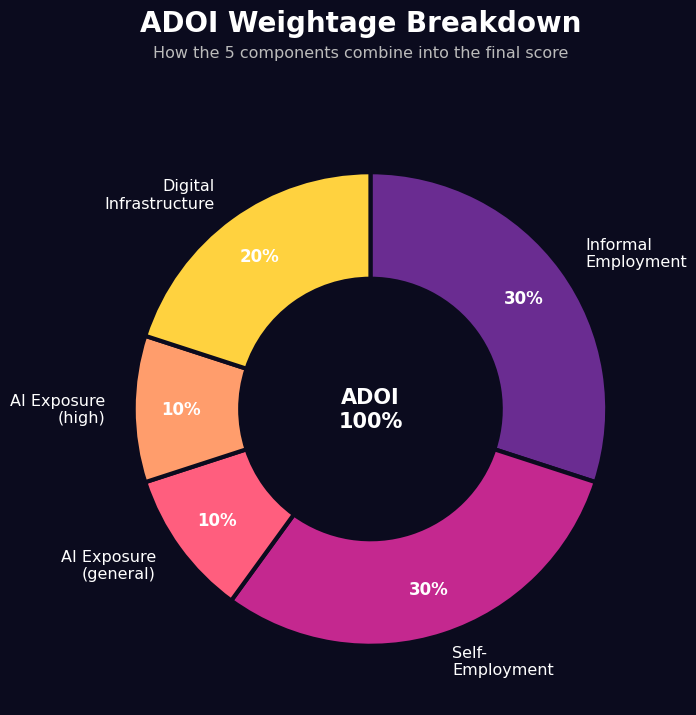

Saved: donut_weightage.svg -- download it from the Colab file browser on the left


In [33]:
# repeat Static donut chart (matplotlib, SVG export for PDF embedding)
labels = ["Informal\nEmployment", "Self-\nEmployment", "AI Exposure\n(general)",
          "AI Exposure\n(high)", "Digital\nInfrastructure"]
values = [30, 30, 10, 10, 20]
colors = ["#6a2c91", "#c4288f", "#ff5e7e", "#ff9d6c", "#ffd23f"]

fig, ax = plt.subplots(figsize=(8, 8), facecolor="#0b0b1e")
ax.set_facecolor("#0b0b1e")

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    colors=colors,
    autopct="%d%%",
    pctdistance=0.80,
    labeldistance=1.12,
    startangle=90,
    counterclock=False,
    wedgeprops=dict(width=0.45, edgecolor="#0b0b1e", linewidth=3),
    textprops=dict(color="white", fontsize=11.5),
)

for at in autotexts:
    at.set_color("white")
    at.set_fontweight("bold")
    at.set_fontsize(12)

ax.text(0, 0, "ADOI\n100%", ha="center", va="center", fontsize=15, color="white", fontweight="bold")

fig.suptitle("ADOI Weightage Breakdown", fontsize=20, fontweight="bold", color="white", y=0.98)
fig.text(0.5, 0.92, "How the 5 components combine into the final score",
          ha="center", fontsize=11.5, color="#bbbbbb")

plt.subplots_adjust(top=0.85)
plt.savefig("donut_weightage.svg", format="svg", facecolor=fig.get_facecolor())
plt.show()

print("Saved: donut_weightage.svg -- download it from the Colab file browser on the left")

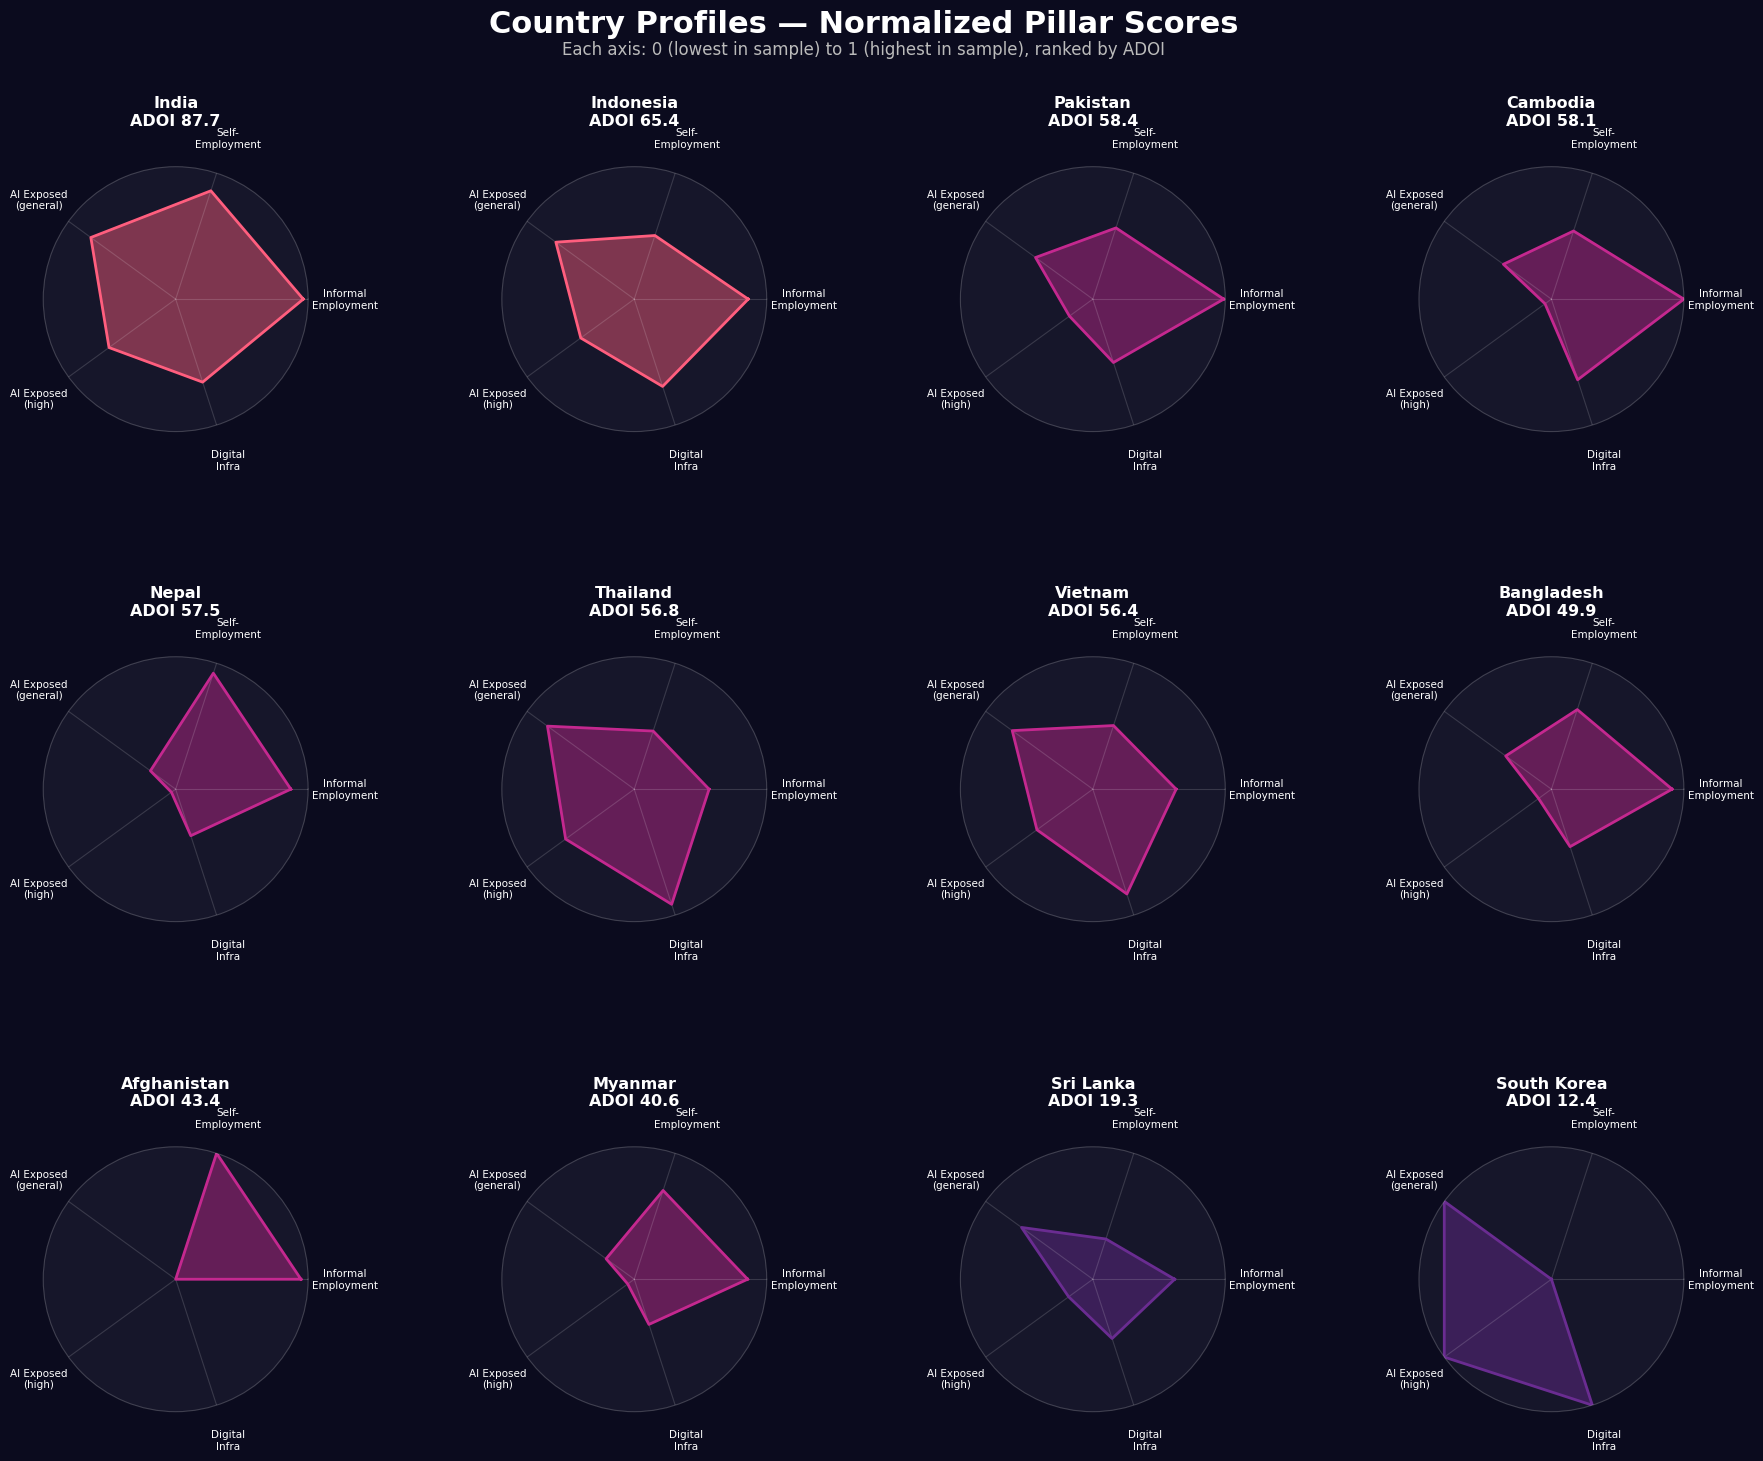

Saved: radar_small_multiples.svg -- download it from the Colab file browser on the left


In [34]:
#Static radar small-multiples (matplotlib, SVG export)


import numpy as np

df_sorted = df_index.sort_values("ADOI", ascending=False).reset_index(drop=True)

categories = ["Informal\nEmployment", "Self-\nEmployment", "AI Exposed\n(general)",
              "AI Exposed\n(high)", "Digital\nInfra"]
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

def tier_color(adoi):
    """Color-code by ADOI tier so the eye can group high/mid/low at a glance."""
    if adoi >= 60:
        return "#ff5e7e"
    elif adoi >= 35:
        return "#c4288f"
    else:
        return "#6a2c91"

fig = plt.figure(figsize=(18, 15), facecolor="#0b0b1e")
fig.suptitle("Country Profiles — Normalized Pillar Scores", fontsize=22, fontweight="bold", color="white", y=0.975)
fig.text(0.5, 0.945, "Each axis: 0 (lowest in sample) to 1 (highest in sample), ranked by ADOI",
          ha="center", fontsize=12, color="#bbbbbb")

n_rows, n_cols = 3, 4
for idx, row in df_sorted.iterrows():
    ax = fig.add_subplot(n_rows, n_cols, idx + 1, polar=True, facecolor="#16162a")
    vals = [row["norm_informal"], row["norm_self_emp"], row["norm_ai_exposed"],
            row["norm_ai_high"], row["norm_internet"]]
    vals += vals[:1]
    color = tier_color(row["ADOI"])

    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.45)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=7.5, color="white")
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.grid(color="white", alpha=0.15)
    ax.spines['polar'].set_color("white")
    ax.spines['polar'].set_alpha(0.2)

    # push the angular tick labels (incl. "Self-Employment" at the top) outward
    # so there's a visible gap before the title sitting above them
    ax.tick_params(axis='x', pad=16)

    # extra top padding keeps the title clear of the "Self-Employment" label
    ax.set_title(f"{row['country']}\nADOI {row['ADOI']}", fontsize=11.5, color="white",
                 fontweight="bold", pad=30)

# generous row/column spacing so nothing from one subplot bleeds into the next
plt.subplots_adjust(left=0.03, right=0.97, top=0.87, bottom=0.04, hspace=0.85, wspace=0.45)

plt.savefig("radar_small_multiples.svg", format="svg", facecolor=fig.get_facecolor())
plt.show()

print("Saved: radar_small_multiples.svg -- download it from the Colab file browser on the left")

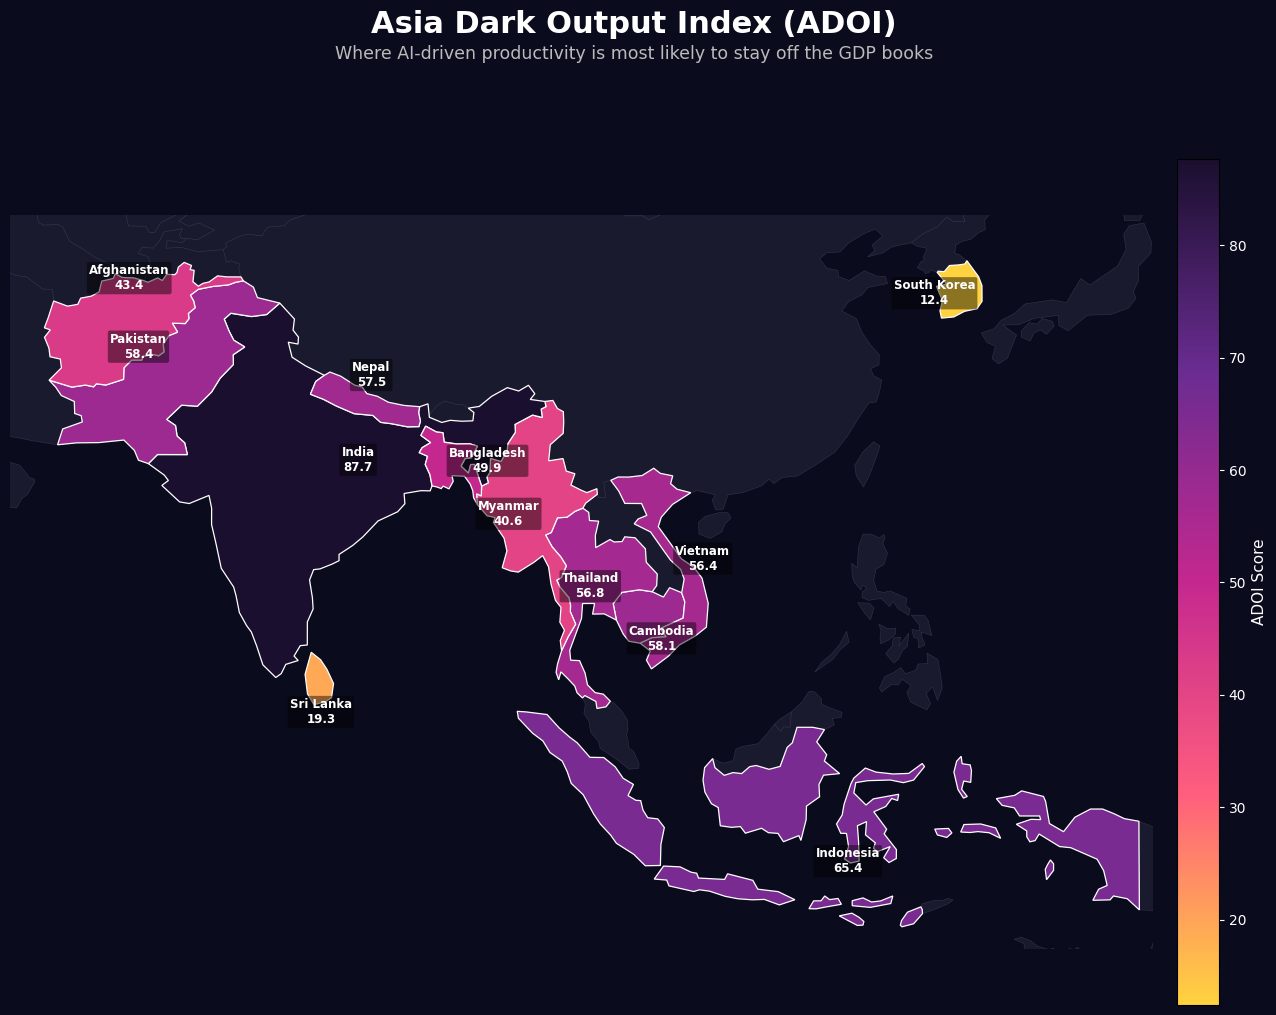

Saved: asia_map.svg -- download it from the Colab file browser on the left


In [35]:
# static Asia map (matplotlib, SVG export for PDF embedding)
# Plotly's choropleth renders great in a browser, but its HTML/JS output
# doesn't embed nicely in a PDF :(

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon as MplPolygon
import json
import urllib.request

plt.rcParams['font.family'] = 'DejaVu Sans'

# Public-domain country boundary data (Natural Earth, via GitHub) --
# fetched at runtime so we don't have to ship a large file with the notebook
GEOJSON_URL = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
with urllib.request.urlopen(GEOJSON_URL) as resp:
    world = json.load(resp)

adoi_lookup = dict(zip(df_index["iso3"], df_index["ADOI"]))
name_lookup = dict(zip(df_index["iso3"], df_index["country"]))

# "Going dark" gradient, literally: low ADOI = bright gold (still visible
# in GDP), high ADOI = deep near-black purple (output has gone dark)
cmap = mcolors.LinearSegmentedColormap.from_list(
    "dark_output", ["#ffd23f", "#ff5e7e", "#c4288f", "#6a2c91", "#1a0f2e"]
)
norm = mcolors.Normalize(vmin=df_index["ADOI"].min(), vmax=df_index["ADOI"].max())

fig, ax = plt.subplots(figsize=(13, 11), facecolor="#0b0b1e")
ax.set_facecolor("#0b0b1e")

def add_polygon(coords, **kwargs):
    ax.add_patch(MplPolygon(coords, closed=True, **kwargs))

label_points = {}

for feature in world["features"]:
    iso3 = feature["properties"].get("ISO_A3") or feature["properties"].get("ADM0_A3")
    geom = feature["geometry"]
    is_focus = iso3 in adoi_lookup
    facecolor = cmap(norm(adoi_lookup[iso3])) if is_focus else "#1a1a2e"
    edgecolor = "white" if is_focus else "#33334a"
    lw = 0.9 if is_focus else 0.4
    zorder = 3 if is_focus else 1

    polys = geom["coordinates"] if geom["type"] == "MultiPolygon" else [geom["coordinates"]]
    biggest, biggest_len = None, 0
    for poly in polys:
        ring = poly[0]
        add_polygon(ring, facecolor=facecolor, edgecolor=edgecolor, linewidth=lw, zorder=zorder)
        if len(ring) > biggest_len:
            biggest_len = len(ring)
            biggest = ring
    if is_focus and biggest:
        xs = [p[0] for p in biggest]
        ys = [p[1] for p in biggest]
        label_points[iso3] = (sum(xs) / len(xs), sum(ys) / len(ys))

# Hand-tuned nudges so labels don't overlap in the densely packed region
label_offsets = {
    "BGD": (2.5, 0.5), "NPL": (0, 2.0), "LKA": (0, -2.2), "KHM": (1, -1.8),
    "VNM": (3, 0), "MMR": (-2.5, 0), "PAK": (-2, 1.5), "AFG": (-1, 2.5),
    "THA": (0, 1.5), "IDN": (-2, -3.5), "IND": (0, 0), "KOR": (-1.5, -0.5),
}

for iso3, (lon, lat) in label_points.items():
    dx, dy = label_offsets.get(iso3, (0, 0))
    name, score = name_lookup[iso3], adoi_lookup[iso3]
    ax.annotate(
        f"{name}\n{score}",
        xy=(lon, lat), xytext=(lon + dx, lat + dy),
        fontsize=8.5, color="white", ha="center", va="center", fontweight="bold",
        zorder=5,
        bbox=dict(boxstyle="round,pad=0.18", facecolor="black", alpha=0.45, edgecolor="none"),
    )

# Zoom into South / Southeast Asia
ax.set_xlim(58, 142)
ax.set_ylim(-12, 42)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

fig.suptitle("Asia Dark Output Index (ADOI)", fontsize=22, fontweight="bold", color="white", y=0.97)
fig.text(0.5, 0.925, "Where AI-driven productivity is most likely to stay off the GDP books",
          ha="center", fontsize=12.5, color="#bbbbbb")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("ADOI Score", color="white", fontsize=11)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color="white")

plt.subplots_adjust(top=0.88, bottom=0.02, left=0.02, right=0.95)
plt.savefig("asia_map.svg", format="svg", facecolor=fig.get_facecolor())
plt.show()

print("Saved: asia_map.svg -- download it from the Colab file browser on the left")